# **UPDATE 1:** `EDA`

In [55]:
import pandas as pd
import numpy as np

# don't display warnings
import warnings
warnings.filterwarnings('ignore')

In [56]:
df = pd.read_csv('../data/full.csv')
df.head()

,Headline,Stance,articleBody
0,Police find mass graves with at least '15 bodi...,unrelated,Danny Boyle is directing the untitled film\r\n...
1,Hundreds of Palestinians flee floods in Gaza a...,agree,Hundreds of Palestinians were evacuated from t...
2,"Christian Bale passes on role of Steve Jobs, a...",unrelated,30-year-old Moscow resident was hospitalized w...
3,HBO and Apple in Talks for $15/Month Apple TV ...,unrelated,(Reuters) - A Canadian soldier was shot at the...
4,Spider burrowed through tourist's stomach and ...,disagree,"Fear not arachnophobes, the story of Bunbury's..."


### Separating the data into related and unrelated ones

In [57]:
related_df = df[df['Stance'].isin(['agree', 'disagree', 'discuss'])]
unrelated_df = df[df['Stance'] == 'unrelated']

In [58]:
df['Stance'].value_counts()

Stance
unrelated    54894
discuss      13373
agree         5581
disagree      1537
Name: count, dtype: int64

In [59]:
related_df['Stance'].value_counts()

Stance
discuss     13373
agree        5581
disagree     1537
Name: count, dtype: int64

In [60]:
unrelated_df['Stance'].value_counts()

Stance
unrelated    54894
Name: count, dtype: int64

In [61]:
related_df.to_csv('../data/related.csv', index=False)
unrelated_df.to_csv('../data/unrelated.csv', index=False)

## Stance distribution and Analysis

### Entire dataset

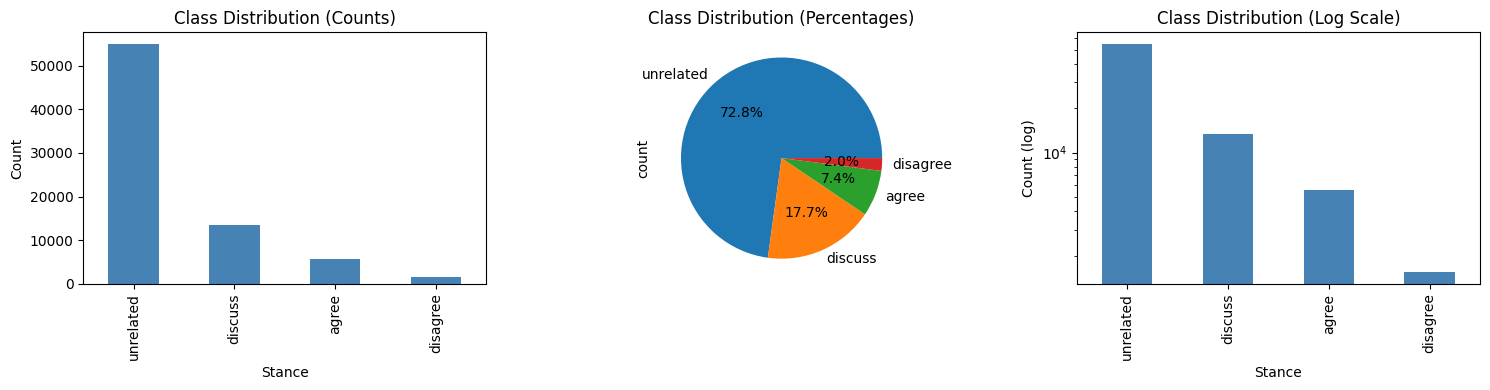

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# Overall distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Bar chart (absolute counts)
df['Stance'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Class Distribution (Counts)')
axes[0].set_ylabel('Count')

# Pie chart (percentages)
df['Stance'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%')
axes[1].set_title('Class Distribution (Percentages)')

# Log scale (to see minority classes)
df['Stance'].value_counts().plot(kind='bar', ax=axes[2], color='steelblue')
axes[2].set_yscale('log')
axes[2].set_title('Class Distribution (Log Scale)')
axes[2].set_ylabel('Count (log)')

plt.tight_layout()
plt.show()

### Only Related

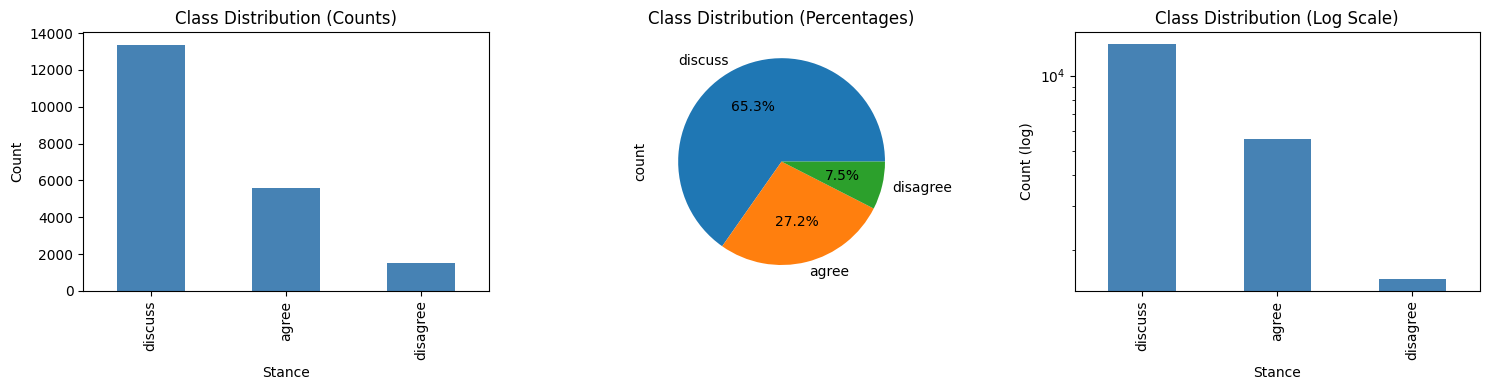

In [63]:
# Overall distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Bar chart (absolute counts)
related_df['Stance'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Class Distribution (Counts)')
axes[0].set_ylabel('Count')

# Pie chart (percentages)
related_df['Stance'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%')
axes[1].set_title('Class Distribution (Percentages)')

# Log scale (to see minority classes)
related_df['Stance'].value_counts().plot(kind='bar', ax=axes[2], color='steelblue')
axes[2].set_yscale('log')
axes[2].set_title('Class Distribution (Log Scale)')
axes[2].set_ylabel('Count (log)')

plt.tight_layout()
plt.show()

From the above distribution, we can see that the dataset is highly imbalanced, with the majority class being "unrelated". 

This imbalance can pose challenges for machine learning models, as they may be biased towards the majority class. It will be important to consider techniques for handling this imbalance, such as resampling or using appropriate evaluation metrics.

### Stance text length distribution

In [64]:
df = df.rename(columns={'Headline': 'headline', 'articleBody': 'body', 'Stance': 'stance'})

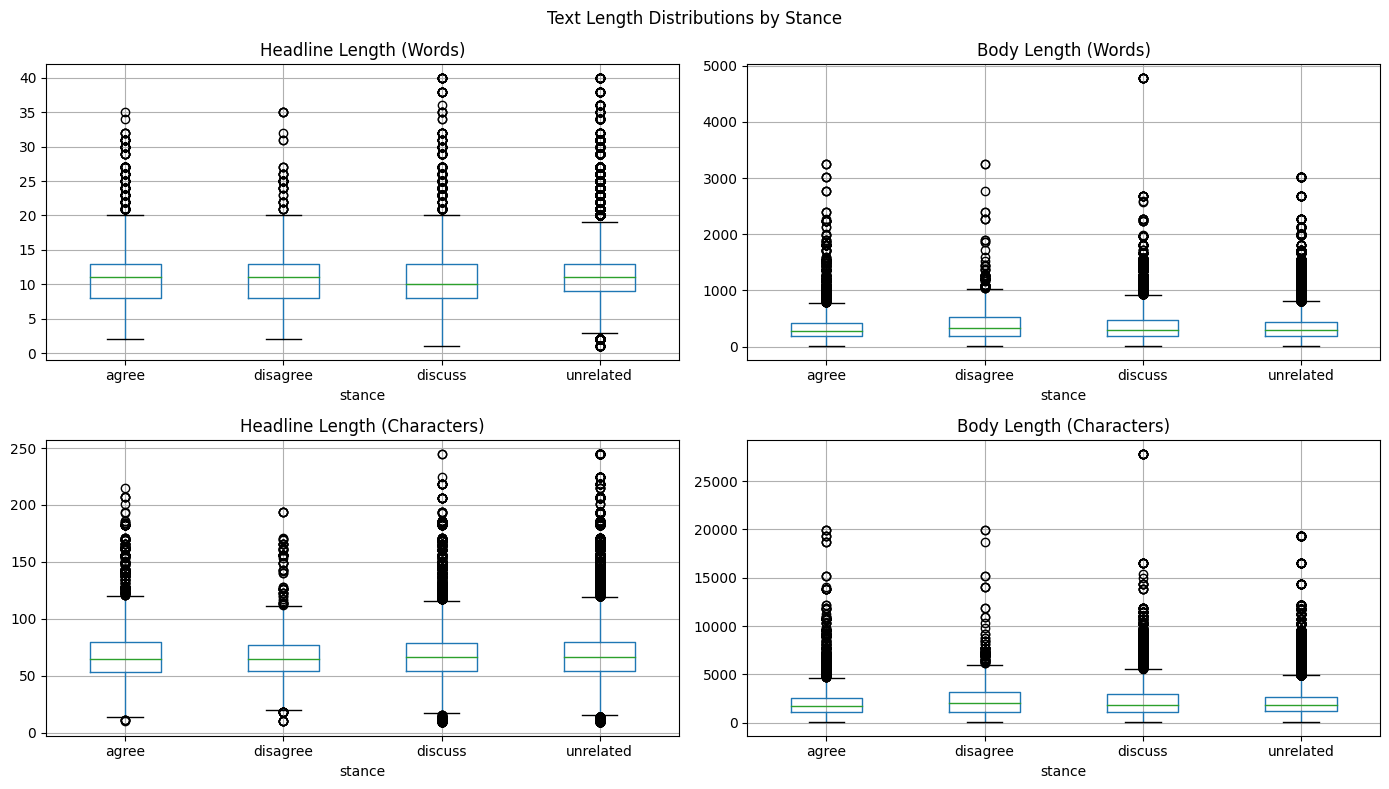

In [65]:
# Add length columns
df['headline_length_words'] = df['headline'].str.split().str.len()
df['headline_length_chars'] = df['headline'].str.len()
df['body_length_words'] = df['body'].str.split().str.len()
df['body_length_chars'] = df['body'].str.len()

# Statistics by stance
df.groupby('stance')[['headline_length_words', 'headline_length_chars', 
                      'body_length_words', 'body_length_chars']].agg(['mean', 'median', 'min', 'max', 'std'])

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

df.boxplot(column='headline_length_words', by='stance', ax=axes[0, 0])
axes[0, 0].set_title('Headline Length (Words)')

df.boxplot(column='body_length_words', by='stance', ax=axes[0, 1])
axes[0, 1].set_title('Body Length (Words)')

df.boxplot(column='headline_length_chars', by='stance', ax=axes[1, 0])
axes[1, 0].set_title('Headline Length (Characters)')

df.boxplot(column='body_length_chars', by='stance', ax=axes[1, 1])
axes[1, 1].set_title('Body Length (Characters)')

plt.suptitle('Text Length Distributions by Stance')
plt.tight_layout()
plt.show()

On avergage, I don't really see that much of a difference in the text length distribution across the different stances. However, there are some outliers in the "disagree" and "discuss" categories that have longer text lengths. As well as the "unrelated" category has some outliers with shorter text lengths.

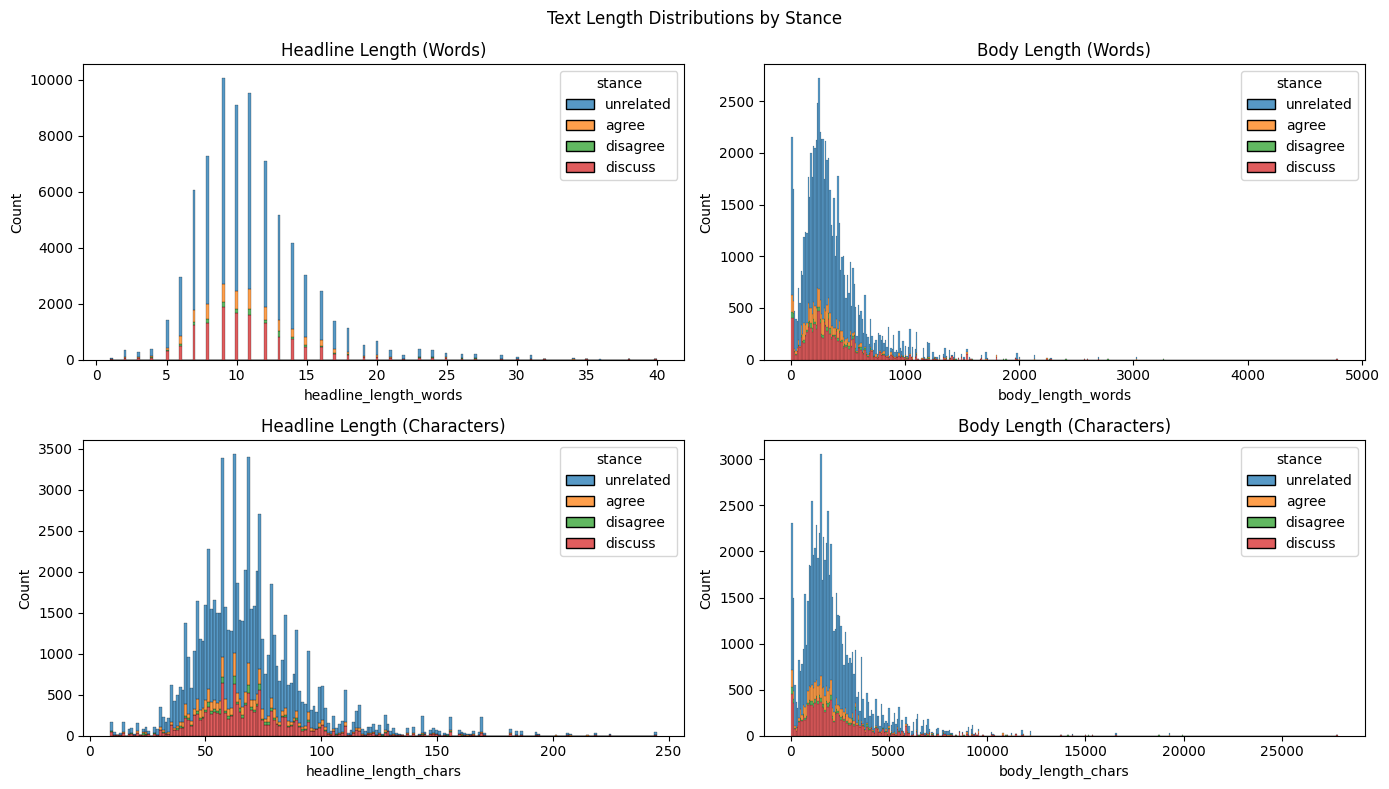

In [66]:
# histograms

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sns.histplot(data=df, x='headline_length_words', hue='stance', ax=axes[0, 0], multiple='stack')
axes[0, 0].set_title('Headline Length (Words)')

sns.histplot(data=df, x='body_length_words', hue='stance', ax=axes[0, 1], multiple='stack')
axes[0, 1].set_title('Body Length (Words)')

sns.histplot(data=df, x='headline_length_chars', hue='stance', ax=axes[1, 0], multiple='stack')
axes[1, 0].set_title('Headline Length (Characters)')

sns.histplot(data=df, x='body_length_chars', hue='stance', ax=axes[1, 1], multiple='stack')
axes[1, 1].set_title('Body Length (Characters)')

plt.suptitle('Text Length Distributions by Stance')
plt.tight_layout()
plt.show()

This was as expected - right skewed with a long tail as some are very long, and most falling in the shorter range. 

But the interesting part is in body lengths, we see a huge spike at lower side (which is different than the spike at mean). This means that there are a lot of bodies that are very short, which is interesting. We will need to look into these short bodies and see if they are valid or if they are noise in the data.

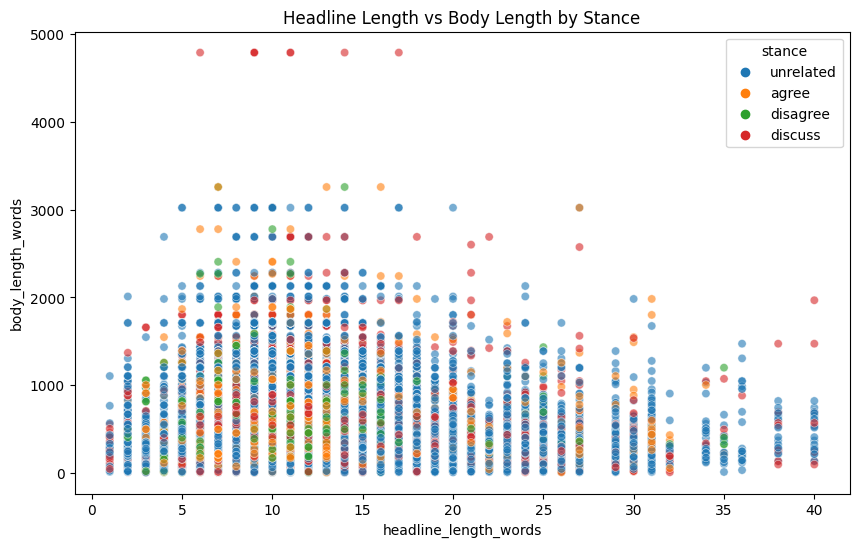

In [67]:
# Scatter plot of headline length vs body length colored by stance
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='headline_length_words', y='body_length_words', hue='stance', alpha=0.6)
plt.title('Headline Length vs Body Length by Stance')
plt.show()

All those extra long bodies are all discusses, which is interesting. We will need to look into these long bodies and see if they are valid or if they are noise in the data.

### Lexical Overlap

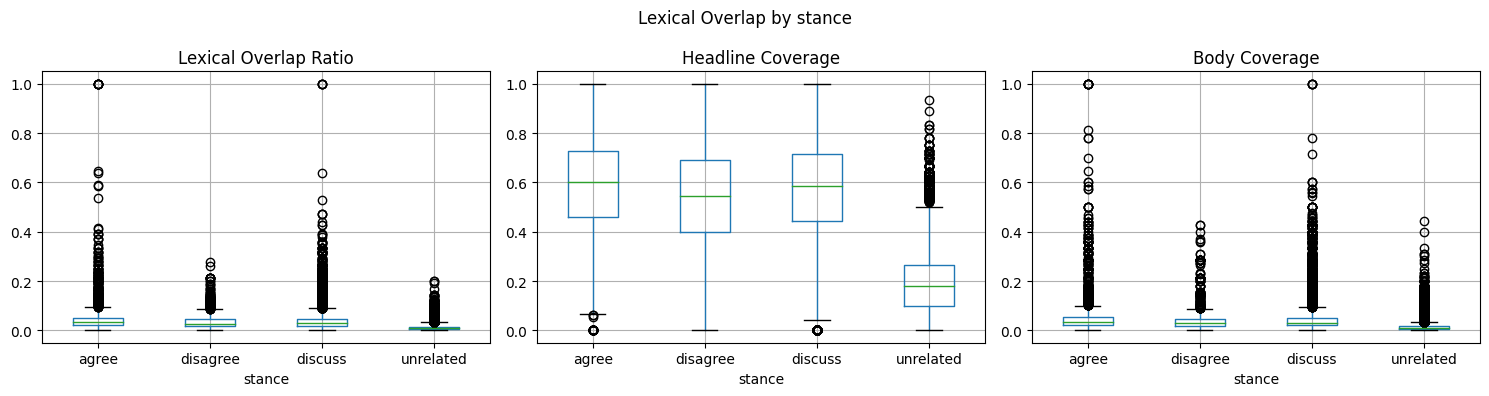

In [68]:
# Function to calculate overlap
def calculate_overlap(headline, body):
    headline_words = set(str(headline).lower().split())
    body_words = set(str(body).lower().split())
    
    overlap = headline_words.intersection(body_words)
    union = headline_words.union(body_words)
    
    if len(union) == 0:
        return 0
    
    overlap_ratio = len(overlap) / len(union)
    headline_coverage = len(overlap) / len(headline_words) if len(headline_words) > 0 else 0
    body_coverage = len(overlap) / len(body_words) if len(body_words) > 0 else 0
    
    return overlap_ratio, headline_coverage, body_coverage

# Apply function
df[['overlap_ratio', 'headline_coverage', 'body_coverage']] = df.apply(
    lambda row: pd.Series(calculate_overlap(row['headline'], row['body'])), 
    axis=1
)

# Statistics by stance
df.groupby('stance')[['overlap_ratio', 'headline_coverage', 'body_coverage']].agg(['mean', 'median', 'min', 'max', 'std'])

# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df.boxplot(column='overlap_ratio', by='stance', ax=axes[0])
axes[0].set_title('Lexical Overlap Ratio')

df.boxplot(column='headline_coverage', by='stance', ax=axes[1])
axes[1].set_title('Headline Coverage')

df.boxplot(column='body_coverage', by='stance', ax=axes[2])
axes[2].set_title('Body Coverage')

plt.suptitle('Lexical Overlap by stance')
plt.tight_layout()
plt.show()

From lexical overlap, we can see that the "unrelated" category has a much lower overlap compared to the other categories. This makes sense, as unrelated articles are less likely to share common words with the headline. The "agree", "disagree", and "discuss" categories have higher overlaps, which indicates that they are more closely related to the headline.

Another thing to note is that the "discuss" and "agree" categories have a slightly higher overlap compared to the "disagree" category. This could be because articles that agree or discuss the headline are more likely to use similar language, while articles that disagree may use different language to express their opposing views.

### Data quality and missing values

In [69]:
# Missing values
print("Missing values:")
print(df.isnull().sum())

# Duplicates
print(f"\nTotal duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate headline-body pairs: {df.duplicated(subset=['headline', 'body']).sum()}")

# Extremely short texts
print(f"\nHeadlines < 5 words: {(df['headline_length_words'] < 5).sum()}")
print(f"Bodies < 10 words: {(df['body_length_words'] < 10).sum()}")
print(f"Empty headlines: {df['headline'].str.strip().eq('').sum()}")
print(f"Empty bodies: {df['body'].str.strip().eq('').sum()}")

Missing values:
headline                 0
stance                   0
body                     0
headline_length_words    0
headline_length_chars    0
body_length_words        0
body_length_chars        0
overlap_ratio            0
headline_coverage        0
body_coverage            0
dtype: int64

Total duplicate rows: 713
Duplicate headline-body pairs: 713

Headlines < 5 words: 994
Bodies < 10 words: 248
Empty headlines: 0
Empty bodies: 0


So, we have some duplicates in the dataset. We also have headlines and bodies that are very short. No empty ones though.

In [70]:
# show duplicate headline-body pairs
duplicate_pairs = df[df.duplicated(subset=['headline', 'body'], keep=False)]
duplicate_pairs.head()

,headline,stance,body,headline_length_words,headline_length_chars,body_length_words,body_length_chars,overlap_ratio,headline_coverage,body_coverage
48,Rumors of ISIS leader's death debunked,unrelated,The CBI registered a case against Gurmeet Ram ...,6,38,255,1572,0.006944,0.166667,0.007194
193,Michelle Obama’s face blurred by Saudi state t...,unrelated,Over the weekend there was a rumor flying arou...,8,55,213,1163,0.006757,0.125000,0.007092
229,Meteorite leaves crater in Nicaraguan capital ...,unrelated,"CHILPANCINGO, Mexico (AP) — Authorities testin...",7,53,1433,9189,0.003929,0.285714,0.003968
340,Saudi cleric condemns snowmen as anti-Islamic,unrelated,Mounted with a cannon and leaving a trail of s...,6,45,559,3293,0.000000,0.000000,0.000000
369,Rumor: Gold Apple Watch Edition priced up to $...,discuss,When Apple introduced its Apple Watch in Septe...,18,97,336,1972,0.043062,0.500000,0.045000


In [71]:
# group and count duplicate groups
dup_groups = duplicate_pairs.groupby(['headline','body']).size().reset_index(name='count').sort_values('count', ascending=False)
dup_groups

,headline,body,count
89,Disturbed aunt cuts off nephew’s penis after h...,A wicked aunt cut her three-year-old nephew’s ...,4
534,Suspended boy threatened to make student disap...,A Grade 4 student was reportedly suspended fro...,3
560,Two GOP Congressmen Say Suspected Terrorists C...,A Texas National Guard soldier scans the Mexic...,3
103,Evil Aunt Hacks Off Toddlers Penis,A wicked aunt cut her three-year-old nephew’s ...,3
474,"Source: Joan Rivers' doc did biopsy, selfie",(CNN) —The cardiac arrest leading to Joan Rive...,3
...,...,...,...
239,Joan Rivers Personal Doctor Allegedly Took A S...,Raven-Symone did NOT file molestation charges ...,2
240,Joan Rivers Personal Doctor Allegedly Took A S...,"Rivers, 81, had checked in for routine throat ...",2
241,Joan Rivers Personal Doctor Allegedly Took A S...,TEHRAN (FNA)- Iraq’s army has shot down two Br...,2
242,Joan Rivers Personal Doctor Allegedly Took A S...,THE scourge of ISIS — a female Kurdish warrior...,2


All these duplicates are the result of headline-body mix to create more unrelated samples.

In [72]:
# Healines under 5 words and bodies under 10 words are mostly duplicates.

df[(df['headline_length_words'] < 5) & (df['body_length_words'] < 10)]

,headline,stance,body,headline_length_words,headline_length_chars,body_length_words,body_length_chars,overlap_ratio,headline_coverage,body_coverage
6180,ISIS leader dead?,unrelated,I aborted my baby because it was a boy,3,17,9,38,0.000000,0.000000,0.000000
21578,Batmobile wasn't stolen: Cops,unrelated,I aborted my baby because it was a boy,4,29,9,38,0.000000,0.000000,0.000000
43016,ISIS leader dead?,discuss,A US airstrike allegedly killed ISIS leader Al...,3,17,8,56,0.222222,0.666667,0.250000
57809,Breast Chancer,discuss,The third breast story is a hoax.,2,14,7,33,0.125000,0.500000,0.142857
59311,President Sisi's Gift,unrelated,Microsoft will buy Mojang AB.,3,21,5,29,0.000000,0.000000,0.000000
59318,3-Boobed Woman a Fake,agree,The third breast story is a hoax.,4,21,7,33,0.100000,0.250000,0.142857
63053,Meet the 3-boobed woman,disagree,The third breast story is a hoax.,4,23,7,33,0.100000,0.250000,0.142857


Some of these make sense, I think maybe we can keep these rows.

In [73]:
# Headlines under 5 words

df[df['headline_length_words'] < 5]

,headline,stance,body,headline_length_words,headline_length_chars,body_length_words,body_length_chars,overlap_ratio,headline_coverage,body_coverage
10,Gateway Pundit,discuss,A British rapper whose father is awaiting tria...,2,14,458,2752,0.000000,0.000000,0.000000
42,Seth Rogen Is Woz,unrelated,"Last year, a Vine from President Obama’s trip ...",4,17,61,396,0.017241,0.250000,0.018182
57,Bali Awry,unrelated,While Apple announced that the base model of i...,2,9,195,1113,0.000000,0.000000,0.000000
73,Batmobile wasn't stolen: Cops,unrelated,"The news has gone around the world, including ...",4,29,377,2115,0.000000,0.000000,0.000000
237,ISIS Getting Ebola,unrelated,DNA tests have confirmed that a daughter and a...,3,18,516,3142,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...
75374,Why Obamacare failed,disagree,"Congressional Republicans, evidently hoping th...",3,20,1055,6525,0.001923,0.333333,0.001931
75375,Why Obamacare failed,discuss,Did Obamacare work?\r\n\r\nIt’s worth reflecti...,3,20,1658,10376,0.002853,0.666667,0.002857
75376,Why Obamacare failed,agree,Millions may lose coverage next year if Congre...,3,20,1001,6197,0.002222,0.333333,0.002232
75377,Why Obamacare failed,agree,"Come November, the grim trudge across the incr...",3,20,909,5720,0.006110,1.000000,0.006110


In [74]:
# single word headlines
df[df['headline_length_words'] == 1]

,headline,stance,body,headline_length_words,headline_length_chars,body_length_words,body_length_chars,overlap_ratio,headline_coverage,body_coverage
50110,Crabzilla,unrelated,Police are looking for the married lovers of s...,1,9,158,843,0.000000,0.0,0.000000
50409,Crabzilla,unrelated,British jihadist al-Britani was reportedly kil...,1,9,13,78,0.000000,0.0,0.000000
51000,Crabzilla,unrelated,The Apple Watch will reportedly be available i...,1,9,225,1300,0.000000,0.0,0.000000
51179,Crabzilla,unrelated,Either Lenovo is very serious about stepping u...,1,9,416,2393,0.000000,0.0,0.000000
51241,Crabzilla,unrelated,Apple originally planned for the Apple Watch t...,1,9,289,1731,0.000000,0.0,0.000000
52218,Crabzilla,unrelated,Tonight's Australian Open coverage on ESPN2 fe...,1,9,98,607,0.000000,0.0,0.000000
52730,Crabzilla,discuss,THIS seaside town might be famed for its oyste...,1,9,283,1621,0.000000,0.0,0.000000
53038,Crabzilla,discuss,A marine biologist has killed off claims that ...,1,9,457,2575,0.004202,1.0,0.004202
53632,Crabzilla,discuss,The crabs human see or eat are usually only si...,1,9,199,1078,0.000000,0.0,0.000000
53943,Crabzilla,discuss,“The aerial shot enables viewers to see the fu...,1,9,114,647,0.000000,0.0,0.000000


`Carbzilla`: it's the only one-word headline, and it is a real word, so I think we can keep it. There are some discusses there

In [75]:
# 10 words bodies

df[df['body_length_words'] <= 10]

,headline,stance,body,headline_length_words,headline_length_chars,body_length_words,body_length_chars,overlap_ratio,headline_coverage,body_coverage
383,Report: Former Baseball Star Jose Canseco Acci...,unrelated,Google has bought about half of Pacific Shores...,10,67,10,59,0.000000,0.000000,0.000000
623,Zack Snyder Makes Fun of Stolen Batmobile Rumo...,unrelated,I aborted my baby because it was a boy,11,62,9,38,0.000000,0.000000,0.000000
1236,Cameron vows to hunt down IS 'monsters' after ...,discuss,An unverified video shows the beheading of Dav...,10,59,9,55,0.055556,0.100000,0.111111
1370,Zack Snyder’s ‘Batman V Superman: Dawn Of Just...,unrelated,I aborted my baby because it was a boy,14,85,9,38,0.000000,0.000000,0.000000
1403,Kidnapped Nigerian schoolgirls: Government cla...,unrelated,Google has bought about half of Pacific Shores...,16,115,10,59,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...
74656,"Next-gen iPhone rumored to sport dual-lenses, ...",unrelated,Egyptian President al-Sisi reportedly offered ...,13,88,10,71,0.045455,0.076923,0.100000
74778,Fox Affiliate Falls for College Humor's Office...,agree,This Is The Most Passive-Aggressive Office Bat...,10,61,10,65,0.052632,0.100000,0.100000
74979,The Story of the 3-Boobed Lady Is As Fake As H...,agree,The third breast story is a hoax.,13,59,7,33,0.285714,0.363636,0.571429
75062,Charles Manson's fiancee used him for his ... ...,unrelated,The third breast story is a hoax.,9,53,7,33,0.000000,0.000000,0.000000


In [76]:
df[df['body_length_words'] <= 10].groupby(['headline','body']).size().reset_index(name='count').sort_values('count', ascending=False)

,headline,body,count
318,Suspended boy threatened to make student disap...,The third breast story is a hoax.,2
385,"Wife chops off cheating husband’s penis, twice",Hearing Unconfirmed Reports of Saudi Pipeline ...,2
372,WHO says reports of suspected Ebola cases in I...,Google has bought about half of Pacific Shores...,2
0,#HairGate: iPhone 6 Customers Are Complaining ...,Google has bought about half of Pacific Shores...,1
275,Report: ISIS Leader Abu Bakr Al-Baghdadi Assas...,A US airstrike allegedly killed ISIS leader Al...,1
...,...,...,...
136,HBO and Apple in Talks for $15/Month Apple TV ...,Google has bought about half of Pacific Shores...,1
135,Government fires employee who skipped work for...,Google has bought about half of Pacific Shores...,1
134,"Google to buy big chunk of Pacific Shores, ico...",Google has bought about half of Pacific Shores...,1
133,Google to Buy Redwood City Offices for $585M,Google has bought about half of Pacific Shores...,1


Most of these bodies have different headlines, so I think we can keep them as well. They are mostly unrelated, so they won't have much impact on the model performance.

In [77]:
# longer bodies
df[df['body_length_words'] > 4000].groupby(['headline','body']).size().reset_index(name='count').sort_values('count', ascending=False)

,headline,body,count
0,12in Retina MacBook Air release date rumours: ...,Our Retina MacBook Air rumour article brings t...,1
1,Apple 'working on 12-inch MacBook Air',Our Retina MacBook Air rumour article brings t...,1
2,Apple 12-Inch MacBook Air Details Emerge; Devi...,Our Retina MacBook Air rumour article brings t...,1
3,Apple may launch 12-inch MacBook Air with Reti...,Our Retina MacBook Air rumour article brings t...,1
4,Apple's 12-Inch Retina MacBook Air Shown in Ar...,Our Retina MacBook Air rumour article brings t...,1
5,"Is Apple about to launch a totally redesigned,...",Our Retina MacBook Air rumour article brings t...,1
6,Report: A Radically Redesigned 12-Inch MacBook...,Our Retina MacBook Air rumour article brings t...,1
7,"Report: new 12-inch MacBook Air slims down, ha...",Our Retina MacBook Air rumour article brings t...,1


These are nothing special, just some long bodies, we can keep them.

In [78]:
# non-english headline or body

### Cleaning and preprocessing

In [79]:
import re
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import word_tokenize, pos_tag
from nltk.corpus import wordnet

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already

In [80]:
def _pos_tag_to_wordnet(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    if tag.startswith('V'):
        return wordnet.VERB
    if tag.startswith('N'):
        return wordnet.NOUN
    if tag.startswith('R'):
        return wordnet.ADV
    
    return wordnet.NOUN

In [81]:
def safe_pos_tag(tokens):
    try:
        return pos_tag(tokens)
    except LookupError:
        return [(t, 'NN') for t in tokens]

def clean_text(s, remove_stopwords=True, lemmatize=True):
    s = '' if pd.isna(s) else str(s)
    s = s.lower()
    s = re.sub(r'https?://\S+|www\.\S+', ' ', s)            # URLs
    s = re.sub(r'<[^>]+>', ' ', s)                         # HTML tags
    s = re.sub(r'\S+@\S+', ' ', s)                         # emails
    s = re.sub(r'[\r\n]+', ' ', s)
    s = re.sub(r'[^0-9a-z\s]', ' ', s)                     # keep only alnum + space
    s = re.sub(r'\s+', ' ', s).strip()
    if s == '':
        return ''
    tokens = word_tokenize(s)
    if remove_stopwords:
        tokens = [t for t in tokens if t not in stop_words]
    if lemmatize:
        # pos_tags = pos_tag(tokens)
        pos_tags = safe_pos_tag(tokens)
        tokens = [lemmatizer.lemmatize(t, _pos_tag_to_wordnet(pt)) for t, pt in pos_tags]
    return ' '.join(tokens)

#### Adding new cleaned features

In [82]:
df['headline_clean'] = df['headline'].map(lambda x: clean_text(x))
df['body_clean']     = df['body'].map(lambda x: clean_text(x))
df['headline_tokens'] = df['headline_clean'].str.split().map(lambda x: set(x) if isinstance(x, list) else set())
df['body_tokens']     = df['body_clean'].str.split().map(lambda x: set(x) if isinstance(x, list) else set())

In [83]:
def overlap_from_sets(hset, bset):
    union = hset.union(bset)
    inter = hset.intersection(bset)
    if not union:
        return 0.0, 0.0, 0.0
    return len(inter)/len(union), (len(inter)/len(hset) if hset else 0.0), (len(inter)/len(bset) if bset else 0.0)

df[['overlap_clean', 'headline_coverage_clean', 'body_coverage_clean']] = df.apply(
    lambda r: pd.Series(overlap_from_sets(r['headline_tokens'], r['body_tokens'])), axis=1
)

In [84]:
print(df.groupby('stance')[['overlap_ratio','overlap_clean']].agg(['mean','median']).round(4))

# Save cleaned dataset
# df.to_csv('../data/full_clean.csv', index=False)

          overlap_ratio         overlap_clean        
                   mean  median          mean  median
stance                                               
agree            0.0444  0.0345        0.0563  0.0429
disagree         0.0364  0.0275        0.0464  0.0314
discuss          0.0406  0.0308        0.0550  0.0400
unrelated        0.0117  0.0091        0.0042  0.0000


In [85]:
df.head()

,headline,stance,body,headline_length_words,headline_length_chars,body_length_words,body_length_chars,overlap_ratio,headline_coverage,body_coverage,headline_clean,body_clean,headline_tokens,body_tokens,overlap_clean,headline_coverage_clean,body_coverage_clean
0,Police find mass graves with at least '15 bodi...,unrelated,Danny Boyle is directing the untitled film\r\n...,19,115,195,1105,0.013605,0.111111,0.015267,police find mass graf least 15 body near mexic...,danny boyle directing untitled film seth rogen...,"{15, find, least, student, mass, body, town, n...","{sony, anticipated, female, worked, meeting, c...",0.000000,0.000,0.000000
1,Hundreds of Palestinians flee floods in Gaza a...,agree,Hundreds of Palestinians were evacuated from t...,11,65,429,2608,0.043478,0.909091,0.043668,hundred palestinian flee flood gaza israel ope...,hundred palestinian evacuated home sunday morn...,"{dam, gaza, israel, hundred, open, flee, flood...","{unrwa, construction, wadi, homeless, assault,...",0.040462,0.875,0.040698
2,"Christian Bale passes on role of Steve Jobs, a...",unrelated,30-year-old Moscow resident was hospitalized w...,16,91,194,1123,0.028777,0.250000,0.031496,christian bale pass role steve job actor repor...,30 year old moscow resident hospitalized wound...,"{reportedly, job, part, actor, right, christia...","{wife, nature, told, gently, held, sad, became...",0.000000,0.000,0.000000
3,HBO and Apple in Talks for $15/Month Apple TV ...,unrelated,(Reuters) - A Canadian soldier was shot at the...,14,82,80,504,0.027027,0.166667,0.031250,hbo apple talk 15 month apple tv streaming ser...,reuters canadian soldier shot canadian war mem...,"{15, tv, streaming, service, launching, apple,...","{killing, reporting, amran, editing, hopkins, ...",0.000000,0.000,0.000000
4,Spider burrowed through tourist's stomach and ...,disagree,"Fear not arachnophobes, the story of Bunbury's...",10,63,612,3433,0.021605,0.700000,0.021807,spider burrowed tourist stomach chest,fear arachnophobes story bunbury spiderman mig...,"{stomach, chest, spider, burrowed, tourist}","{air, identification, parasitic, framenau, see...",0.014706,0.600,0.014851


## N-Gram anaysis

In [86]:
# N-gram setup
from sklearn.feature_extraction.text import CountVectorizer

stances = ['agree', 'disagree', 'discuss', 'unrelated']

In [87]:
def top_ngrams_by_stance(df, text_col, stance_col='stance', ngram_range=(1, 1), top_k=20, min_df=2):
    rows = []
    for st in stances:
        corpus = df.loc[df[stance_col] == st, text_col].fillna('')
        vectorizer = CountVectorizer(ngram_range=ngram_range, min_df=min_df)
        X = vectorizer.fit_transform(corpus)

        terms = vectorizer.get_feature_names_out()
        counts = X.sum(axis=0).A1
        total = counts.sum()

        tmp = pd.DataFrame({
            'stance': st,
            'ngram': terms,
            'count': counts
        })
        tmp['rel_freq'] = tmp['count'] / total if total > 0 else 0
        tmp = tmp.sort_values('count', ascending=False).head(top_k)
        rows.append(tmp)

    return pd.concat(rows, ignore_index=True)

In [88]:
# Headlines: top unigrams + bigrams
top_uni_head = top_ngrams_by_stance(df, text_col='headline_clean', ngram_range=(1,1), top_k=20, min_df=2)
top_bi_head  = top_ngrams_by_stance(df, text_col='headline_clean', ngram_range=(2,2), top_k=20, min_df=2)

display(top_uni_head.head(20))
display(top_bi_head.head(20))

,stance,ngram,count,rel_freq
0,agree,man,435,0.009675
1,agree,isi,424,0.009430
2,agree,woman,383,0.008518
3,agree,video,301,0.006695
4,agree,hoax,286,0.006361
5,agree,dead,264,0.005872
6,agree,foley,248,0.005516
7,agree,penis,244,0.005427
8,agree,james,232,0.005160
9,agree,president,229,0.005093


,stance,ngram,count,rel_freq
0,agree,justin bieber,161,0.004209
1,agree,argentina president,151,0.003948
2,agree,wright foley,127,0.003321
3,agree,james wright,127,0.003321
4,agree,journalist james,124,0.003242
5,agree,year old,115,0.003007
6,agree,macaulay culkin,108,0.002824
7,agree,james foley,105,0.002745
8,agree,american journalist,105,0.002745
9,agree,islamic state,102,0.002667


In [89]:
# Bodies: top unigrams + bigrams
top_uni_body = top_ngrams_by_stance(df, text_col='body_clean', ngram_range=(1,1), top_k=20, min_df=5)
top_bi_body  = top_ngrams_by_stance(df, text_col='body_clean', ngram_range=(2,2), top_k=20, min_df=5)

display(top_uni_body.head(20))
display(top_bi_body.head(20))

,stance,ngram,count,rel_freq
0,agree,said,12355,0.011098
1,agree,year,5397,0.004848
2,agree,one,4813,0.004323
3,agree,would,4265,0.003831
4,agree,video,4085,0.003669
5,agree,told,3807,0.003420
6,agree,time,3666,0.003293
7,agree,people,3648,0.003277
8,agree,state,3628,0.003259
9,agree,also,3584,0.003219


,stance,ngram,count,rel_freq
0,agree,year old,1994,0.002273
1,agree,islamic state,1631,0.001859
2,agree,new york,757,0.000863
3,agree,united state,607,0.000692
4,agree,social medium,606,0.000691
5,agree,last year,579,0.000660
6,agree,macaulay culkin,502,0.000572
7,agree,boko haram,489,0.000557
8,agree,last week,486,0.000554
9,agree,seventh son,471,0.000537


In [90]:
def plot_top_ngrams(df_top, title, metric='rel_freq'):
    import math
    stances = list(df_top['stance'].unique())
    n = len(stances)
    # number of rows when using 2 columns
    cols = 2
    rows = math.ceil(n / cols)
    # compute max bars per subplot to scale height
    max_bars = df_top.groupby('stance')['ngram'].nunique().max()
    per_plot_height = max(3.0, 0.35 * max_bars)  # adjust multiplier to taste
    figsize = (14, per_plot_height * rows)

    fig, axes = plt.subplots(rows, cols, figsize=figsize, squeeze=False)
    axes = axes.flatten()

    for i, st in enumerate(stances):
        ax = axes[i]
        sub = df_top[df_top['stance'] == st].sort_values(metric, ascending=True)
        sns.barplot(x=metric, y='ngram', data=sub, ax=ax, palette='viridis')
        ax.set_title(st)
        ax.tick_params(axis='y', labelsize=10)
        ax.set_xlabel(metric)
    # hide any unused subplots
    for j in range(len(stances), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

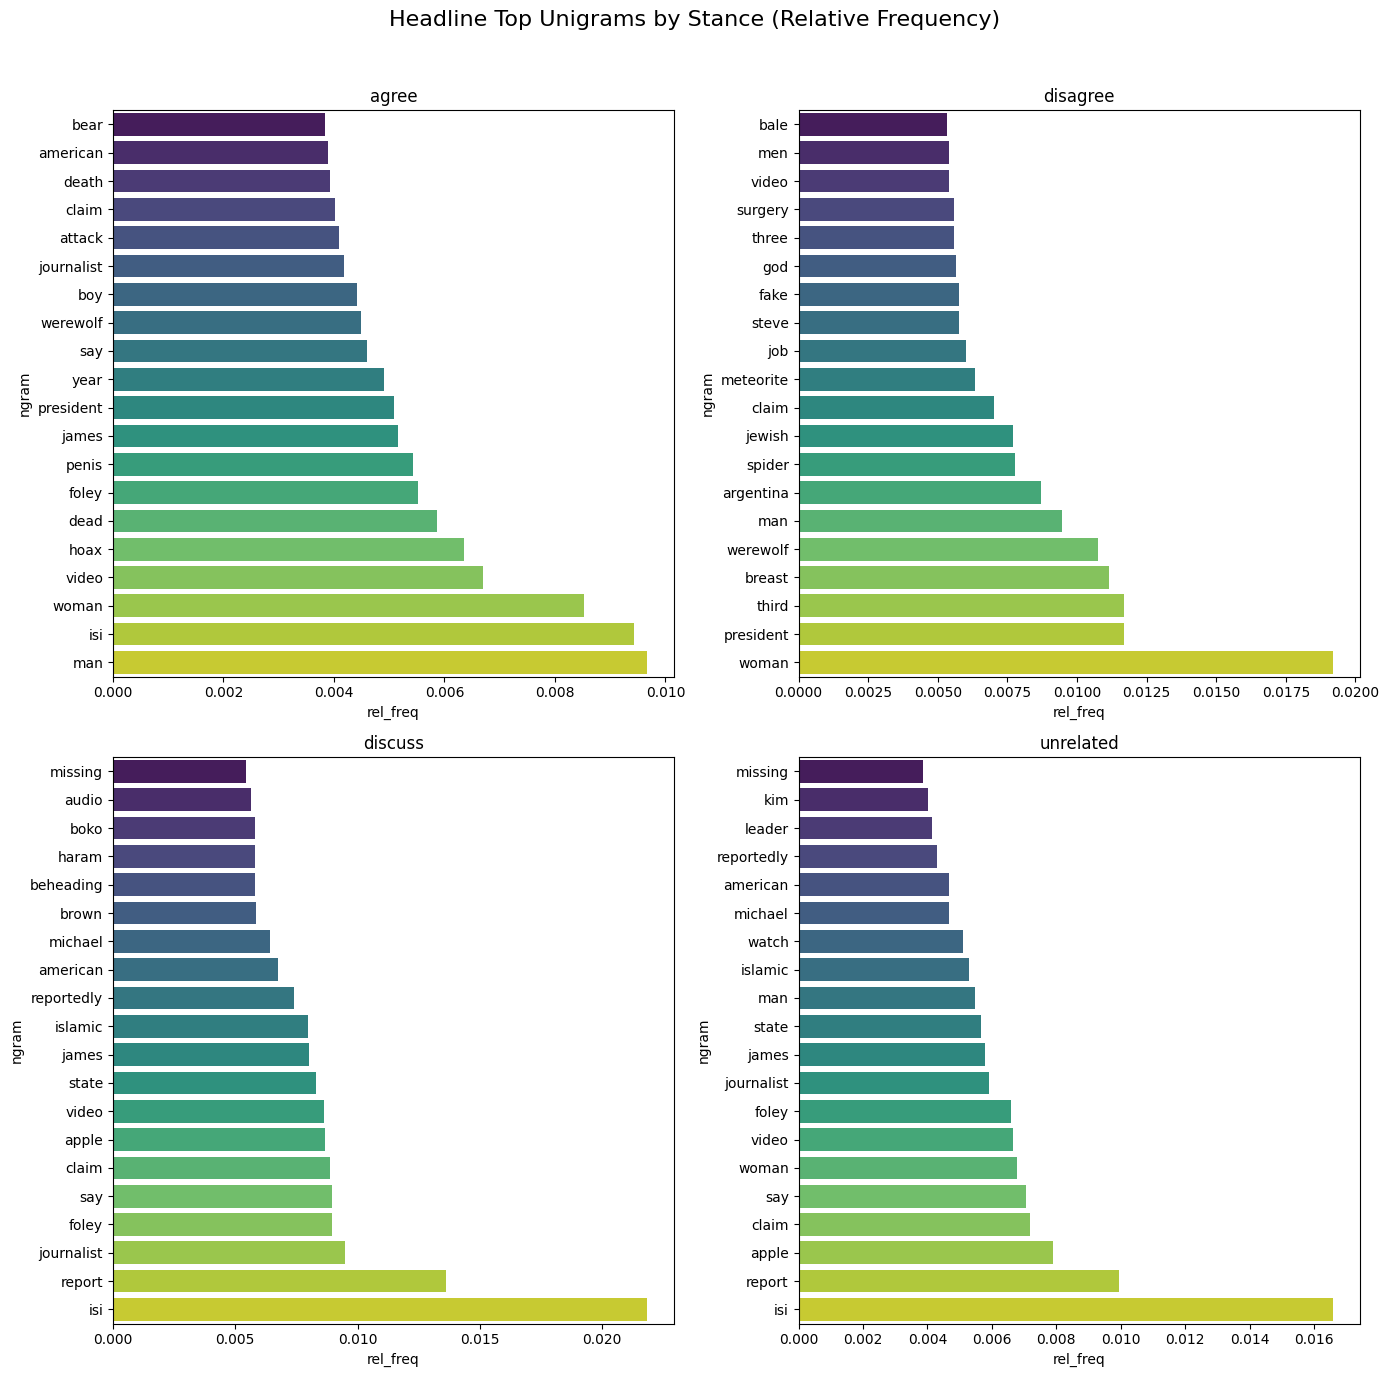

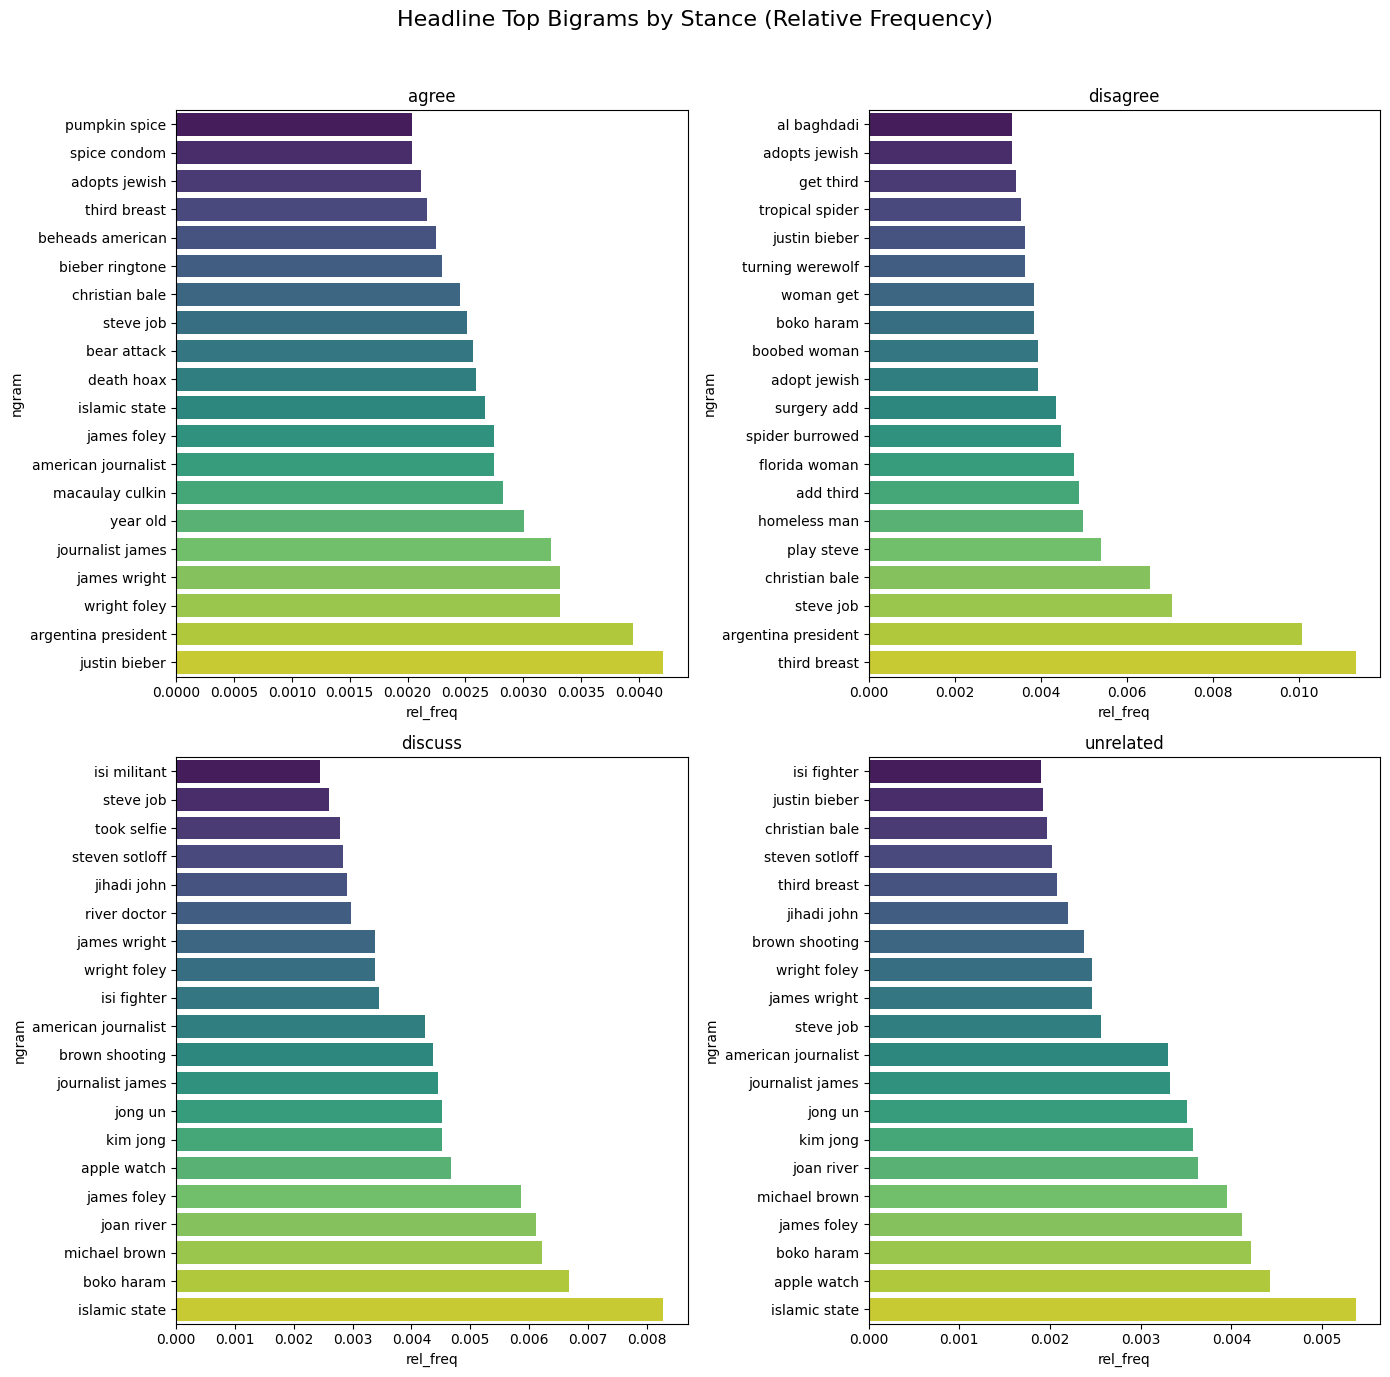

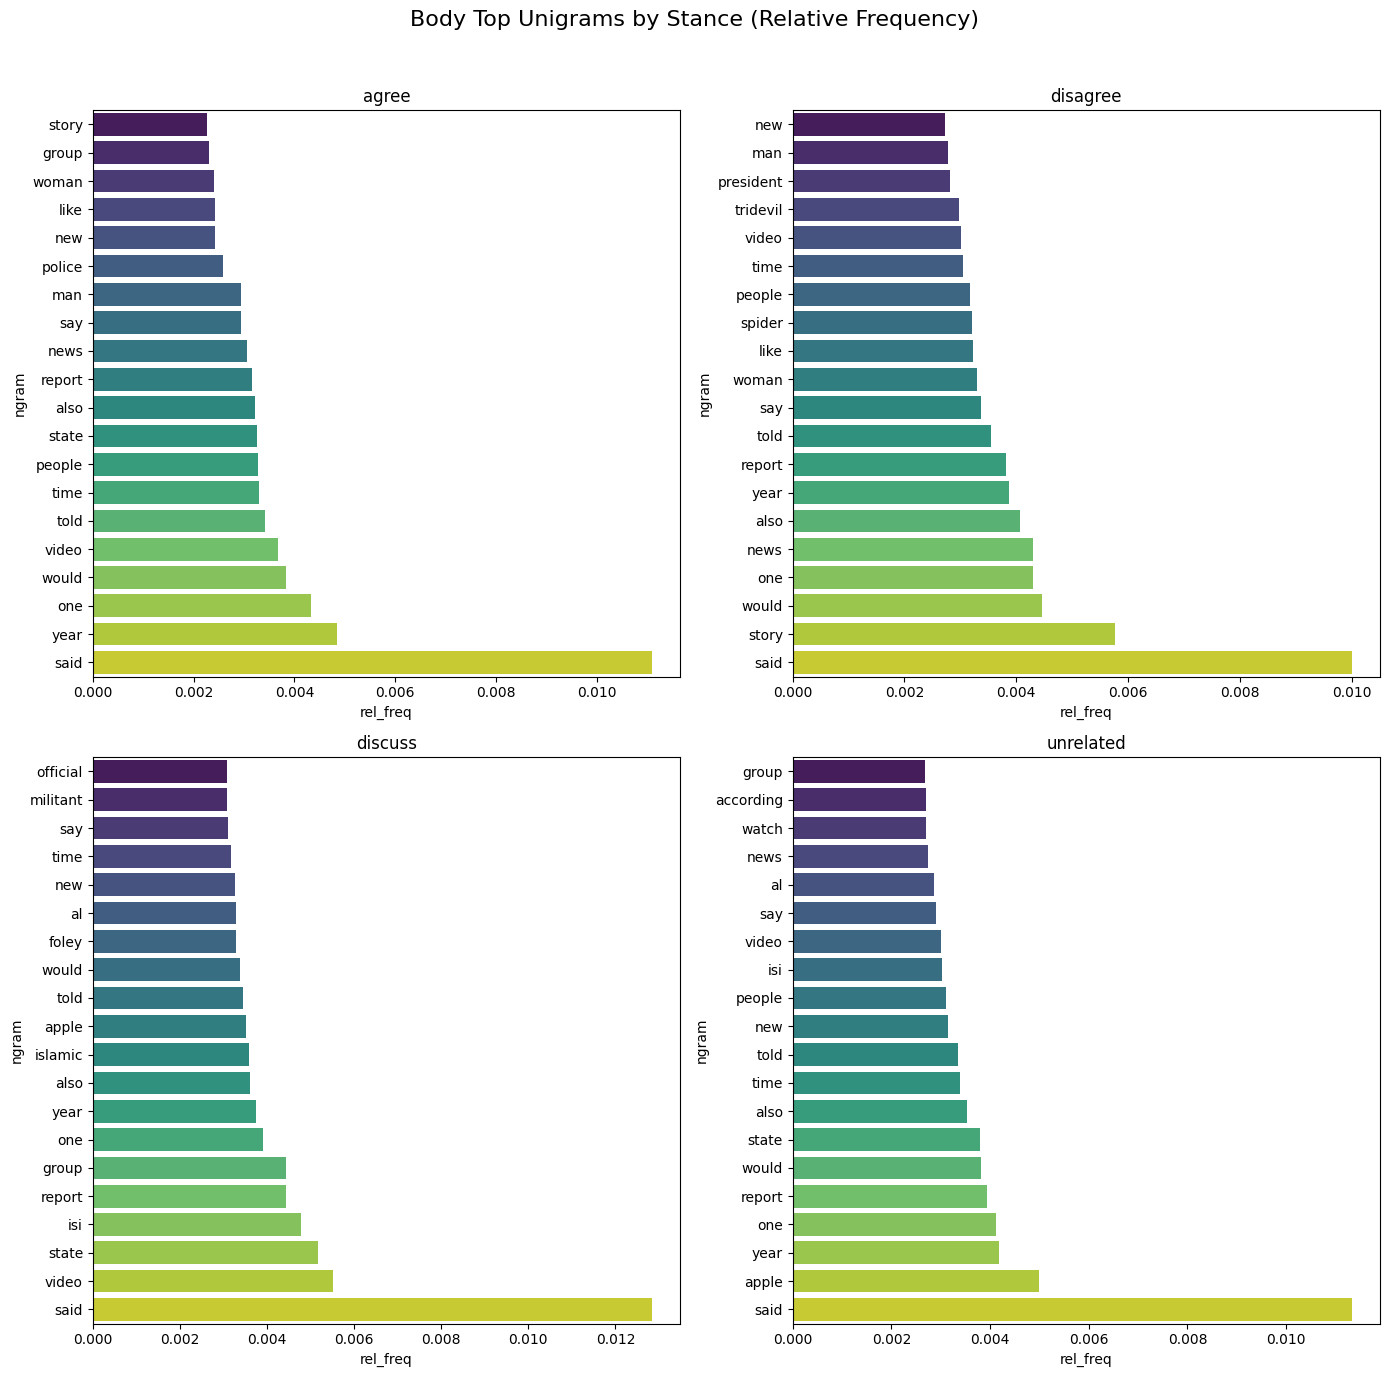

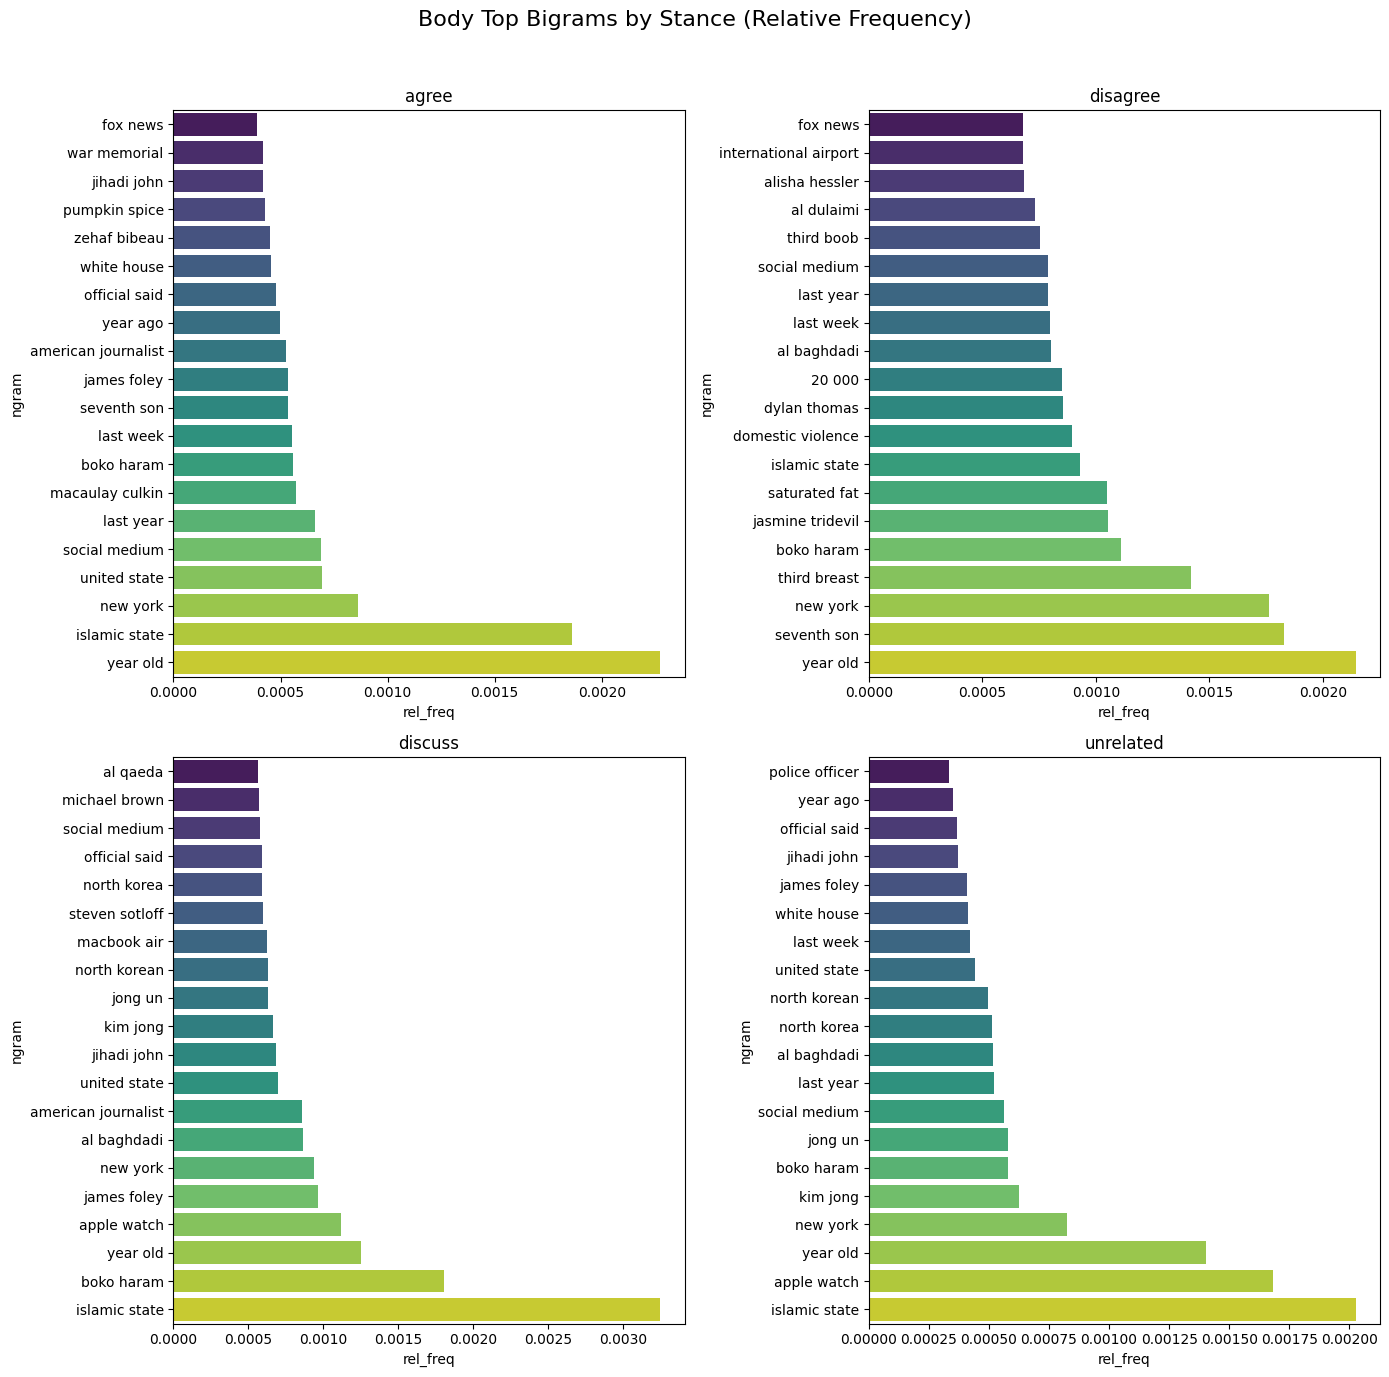

In [91]:
plot_top_ngrams(top_uni_head, 'Headline Top Unigrams by Stance (Relative Frequency)', metric='rel_freq')
plot_top_ngrams(top_bi_head,  'Headline Top Bigrams by Stance (Relative Frequency)', metric='rel_freq')
plot_top_ngrams(top_uni_body, 'Body Top Unigrams by Stance (Relative Frequency)', metric='rel_freq')
plot_top_ngrams(top_bi_body,  'Body Top Bigrams by Stance (Relative Frequency)', metric='rel_freq')

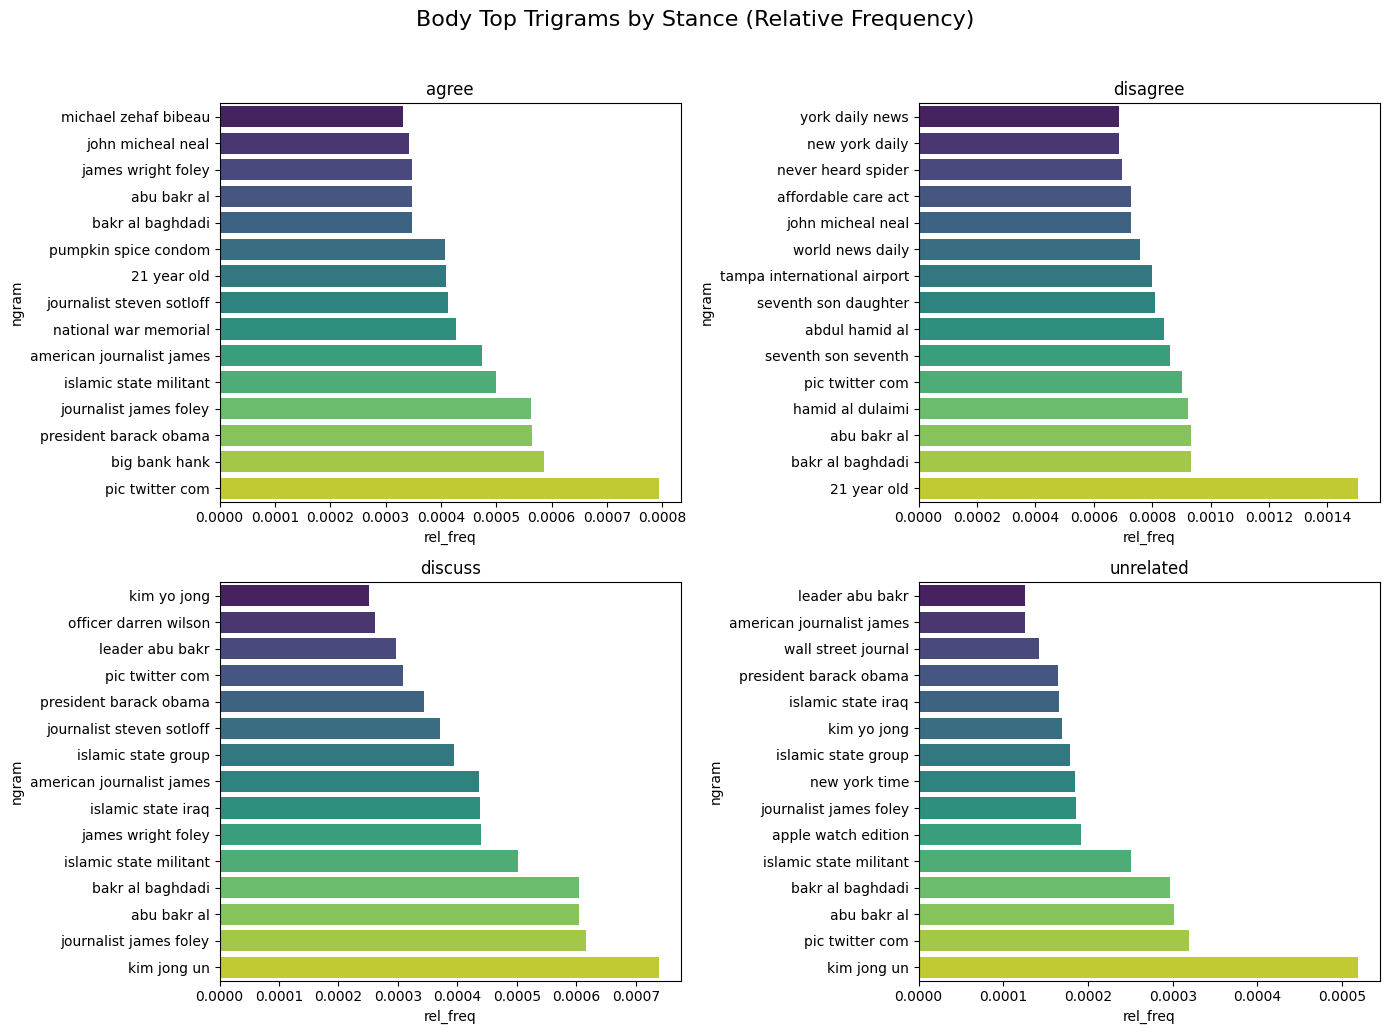

In [92]:
# trigrams
top_tri_body = top_ngrams_by_stance(df, text_col='body_clean', ngram_range=(3,3), top_k=15, min_df=10)
plot_top_ngrams(top_tri_body, 'Body Top Trigrams by Stance (Relative Frequency)', metric='rel_freq')

## Clustering analysis

In [93]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Vectorize cleaned text
vectorizer = TfidfVectorizer(max_features=500, ngram_range=(1,2))
X_tfidf = vectorizer.fit_transform(df['body_clean'])

# Find optimal K using silhouette score
silhouette_scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_tfidf)
    score = silhouette_score(X_tfidf, labels)
    silhouette_scores.append(score)

# Fit final model
best_k = silhouette_scores.index(max(silhouette_scores)) + 2
km_final = KMeans(n_clusters=best_k, random_state=42)
df['cluster'] = km_final.fit_predict(X_tfidf)

# Visualize top words per cluster

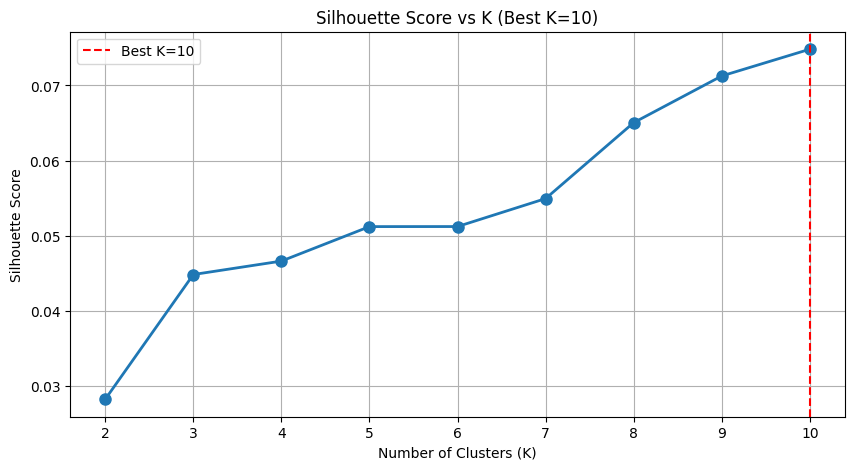

Best number of clusters: 10


In [94]:
# Plot silhouette scores to see which K was optimal
plt.figure(figsize=(10, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title(f'Silhouette Score vs K (Best K={best_k})')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best K={best_k}')
plt.legend()
plt.grid()
plt.show()

print(f"Best number of clusters: {best_k}")

In [95]:
def get_top_words_per_cluster(vectorizer, km_model, top_k=10):
    """Extract and display top TF-IDF words for each cluster"""
    terms = vectorizer.get_feature_names_out()
    centers = km_model.cluster_centers_
    
    for cluster_id in range(km_model.n_clusters):
        top_indices = centers[cluster_id].argsort()[-top_k:][::-1]
        top_words = terms[top_indices]
        print(f"\nCluster {cluster_id}: {', '.join(top_words)}")

get_top_words_per_cluster(vectorizer, km_final, top_k=15)


Cluster 0: animal, dog, said, wife, hospital, child, found, outside, woman, year, man, find, new, old, spokesman

Cluster 1: isi, foley, islamic, video, islamic state, state, syria, journalist, said, american, sotloff, iraq, group, border, militant

Cluster 2: apple, watch, apple watch, iphone, inch, device, company, gold, user, model, feature, new, source, launch, store

Cluster 3: kim, jong, north, korean, korea, kim jong, jong un, un, north korean, north korea, leader, said, official, south, health

Cluster 4: ebola, boko, boko haram, haram, girl, nigerian, government, mosul, health, said, militant, iraqi, group, isi, official

Cluster 5: said, one, new, year, report, police, company, news, would, story, time, people, video, job, also

Cluster 6: shot, brown, shooting, wilson, parliament, police, recording, audio, ferguson, cnn, fired, canadian, officer, michael, said

Cluster 7: river, bear, tridevil, doctor, surgery, cat, procedure, third, clinic, woman, said, operation, phone, t

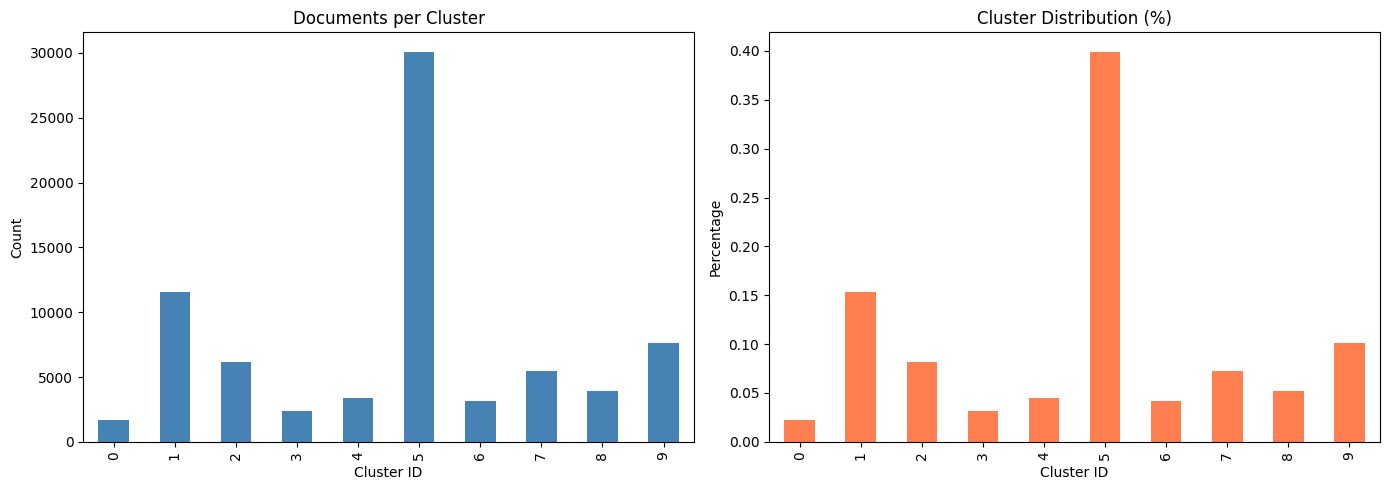

In [96]:
# Bar chart of cluster sizes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolute counts
df['cluster'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Documents per Cluster')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Cluster ID')

# Percentage
df['cluster'].value_counts(normalize=True).sort_index().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Cluster Distribution (%)')
axes[1].set_ylabel('Percentage')
axes[1].set_xlabel('Cluster ID')

plt.tight_layout()
plt.show()

Cluster vs Stance Distribution:
stance   agree  disagree  discuss  unrelated    All
cluster                                            
0          178        24       47       1415   1664
1          658        53     3376       7452  11539
2           54         5      897       5213   6169
3           51         7      503       1801   2362
4          155        51     1116       2039   3361
5         2595       804     4024      22660  30083
6          160        26      848       2144   3178
7          616       269     1169       3408   5462
8          158        57      798       2933   3946
9          956       241      595       5829   7621
All       5581      1537    13373      54894  75385


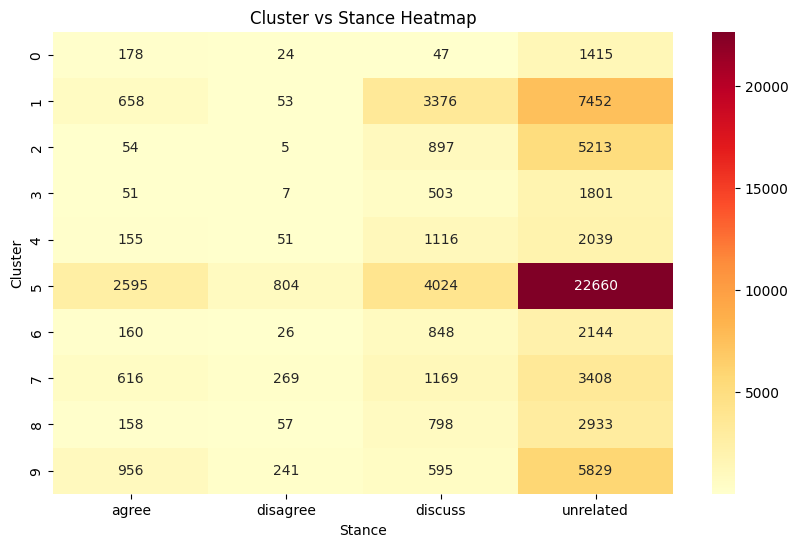

In [97]:
# See how clusters relate to stances
cluster_stance = pd.crosstab(df['cluster'], df['stance'], margins=True)
print("Cluster vs Stance Distribution:")
print(cluster_stance)

# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(df['cluster'], df['stance']), annot=True, fmt='d', cmap='YlOrRd')
plt.title('Cluster vs Stance Heatmap')
plt.ylabel('Cluster')
plt.xlabel('Stance')
plt.show()

In [98]:
# See what articles are actually in each cluster
for cluster_id in range(best_k):
    print(f"\n{'='*80}")
    print(f"CLUSTER {cluster_id} - Sample Headlines:")
    print(f"{'='*80}")
    samples = df[df['cluster'] == cluster_id][['headline', 'stance']].head(5)
    for idx, row in samples.iterrows():
        print(f"  • {row['headline'][:80]} ({row['stance']})")


CLUSTER 0 - Sample Headlines:
  • Catholic Priest Dead For 48 Minutes, Is Miraculously Revived – His Revelations A (unrelated)
  • Pope Francis turns out not to have made pets in heaven comment (disagree)
  • Fidel Castro Dead? Yes, He Is… But The Cuban Leader Is Alive, Death Rumors Prove (unrelated)
  • Audio recording allegedly captures moment Michael Brown was shot (unrelated)
  • Michael Phelps’ alleged girlfriend says she was born intersex (unrelated)

CLUSTER 1 - Sample Headlines:
  • Accused Boston Marathon Bomber Severely Injured In Prison, May Never Walk Or Tal (unrelated)
  • British Aid Worker Confirmed Murdered By ISIS (unrelated)
  • Gateway Pundit (discuss)
  • ISIL Beheads American Photojournalist in Iraq (discuss)
  • Christian Bale Exits Steve Jobs Movie (Exclusive) (unrelated)

CLUSTER 2 - Sample Headlines:
  • Identity of ISIS terrorist known as 'Jihadi John' reportedly revealed (unrelated)
  • N. Korea’s Kim has leg injury but in control (unrelated)
  • Bali Awry (